In [1]:
import sys
sys.path.append('../../homework09/src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('../data/raw/starter_data.csv', parse_dates=['date'])

from features import encode_category_onehot, add_zscore, add_rolling_mean
df = encode_category_onehot(df)
df = add_rolling_mean(df)
df.head()

,category,value,date,category_A,category_B,category_C,value_rolling_mean
0,A,10,2025-08-01,True,False,False,10.000000
1,B,15,2025-08-02,False,True,False,12.500000
2,A,12,2025-08-03,True,False,False,12.333333
3,B,18,2025-08-04,False,True,False,15.000000
4,C,25,2025-08-05,False,False,True,18.333333


In [2]:
feature_cols = ['category_A', 'category_B', 'value_rolling_mean']
X = df[feature_cols]
y = df['value']
X.head()

,category_A,category_B,value_rolling_mean
0,True,False,10.000000
1,False,True,12.500000
2,True,False,12.333333
3,False,True,15.000000
4,False,False,18.333333


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])

Train size: 8 Test size: 2


In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficients:", dict(zip(feature_cols, model.coef_)))
print("Intercept:", model.intercept_)

Coefficients: {'category_A': np.float64(-15.204678362573091), 'category_B': np.float64(-10.845029239766083), 'value_rolling_mean': np.float64(0.14035087719298436)}
Intercept: 24.50584795321634


In [5]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = model.predict(X_test)
residuals = y_test - y_pred

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", round(r2, 3))
print("RMSE:", round(rmse, 3))

R²: 0.986
RMSE: 0.775


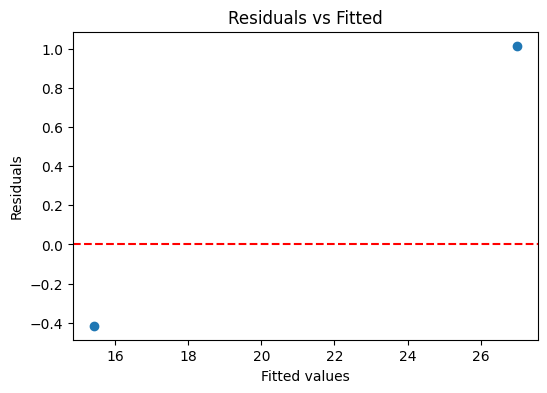

In [6]:
plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted')
plt.show()

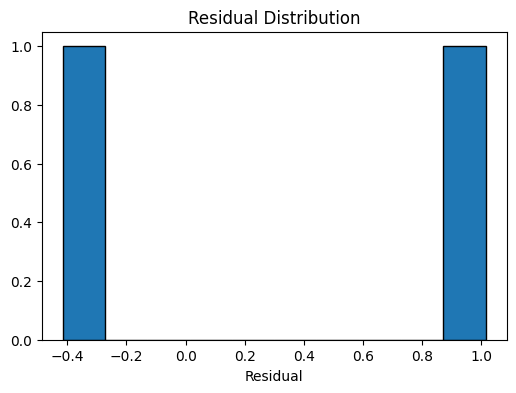

In [7]:
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=10, edgecolor='black')
plt.xlabel('Residual')
plt.title('Residual Distribution')
plt.show()

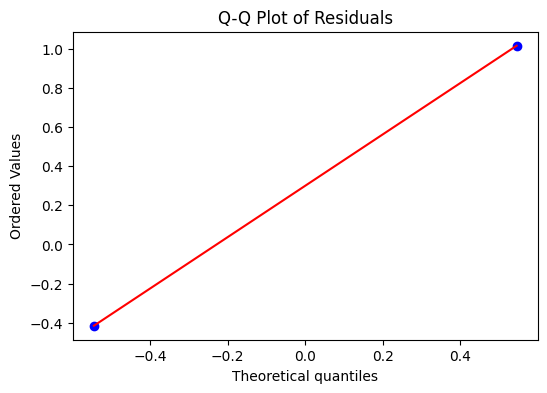

In [8]:
plt.figure(figsize=(6, 4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')
plt.show()

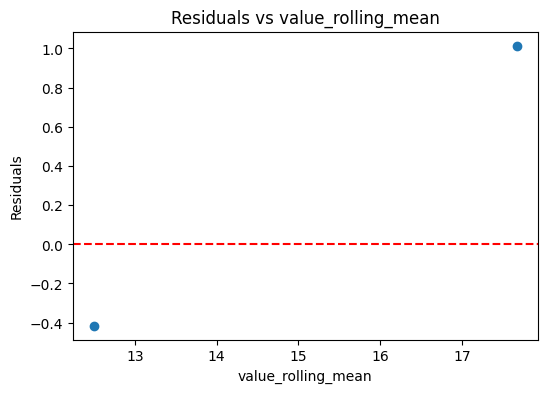

In [9]:
plt.figure(figsize=(6, 4))
plt.scatter(X_test['value_rolling_mean'], residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('value_rolling_mean')
plt.ylabel('Residuals')
plt.title('Residuals vs value_rolling_mean')
plt.show()